# Advanced Mutual Fund Analytics

This notebook computes 95% Historical VaR/CVaR, rolling 90-day Sharpe, investor cohorts, SIP continuity, a simple Sharpe-based recommender, and sector HHI concentration.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
var_cvar = pd.read_csv(ROOT / "var_cvar_report.csv")
fund_master = pd.read_csv(ROOT / "data" / "processed" / "fund_master_cleaned.csv")
transactions = pd.read_csv(ROOT / "data" / "processed" / "investor_transactions_cleaned.csv", parse_dates=["transaction_date"])
holdings = pd.read_csv(ROOT / "data" / "processed" / "portfolio_holdings_cleaned.csv")
scorecard = pd.read_csv(ROOT / "reports" / "performance_analytics" / "fund_scorecard.csv")
display(var_cvar.head())

,amfi_code,scheme_name,fund_house,category,sub_category,plan,risk_category,observations,var_95_daily_return,cvar_95_daily_return,var_95_loss_pct,cvar_95_loss_pct
0,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Regular,Very High,1607,-0.023915,-0.030289,2.391462,3.028854
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Small Cap,Regular,Very High,1607,-0.023284,-0.029690,2.328360,2.969004
2,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Direct,Very High,1607,-0.023155,-0.030163,2.315543,3.016286
3,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Small Cap,Regular,Very High,1607,-0.022810,-0.029940,2.280981,2.993962
4,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,Regular,Very High,1607,-0.021520,-0.028573,2.152030,2.857253


## Historical VaR and CVaR

In [2]:
display(
    var_cvar.sort_values("var_95_daily_return")
    .head(10)
    [["scheme_name", "risk_category", "var_95_daily_return", "cvar_95_daily_return", "var_95_loss_pct", "cvar_95_loss_pct"]]
)

,scheme_name,risk_category,var_95_daily_return,cvar_95_daily_return,var_95_loss_pct,cvar_95_loss_pct
0,ABSL Small Cap Fund - Regular - Growth,Very High,-0.023915,-0.030289,2.391462,3.028854
1,Axis Small Cap Fund - Regular - Growth,Very High,-0.023284,-0.029690,2.328360,2.969004
2,SBI Small Cap Fund - Direct Plan - Growth,Very High,-0.023155,-0.030163,2.315543,3.016286
3,Nippon India Small Cap Fund - Regular - Growth,Very High,-0.022810,-0.029940,2.280981,2.993962
4,DSP Small Cap Fund - Regular - Growth,Very High,-0.021520,-0.028573,2.152030,2.857253
5,SBI Small Cap Fund - Regular Plan - Growth,Very High,-0.021502,-0.028444,2.150192,2.844427
6,Axis Midcap Fund - Regular - Growth,High,-0.016997,-0.022375,1.699654,2.237453
7,Kotak Emerging Equity Fund - Regular - Growth,High,-0.016950,-0.021251,1.694994,2.125069
8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,-0.016902,-0.021850,1.690163,2.184984
9,UTI Mid Cap Fund - Regular - Growth,High,-0.016857,-0.021771,1.685705,2.177063


## Rolling 90-Day Sharpe

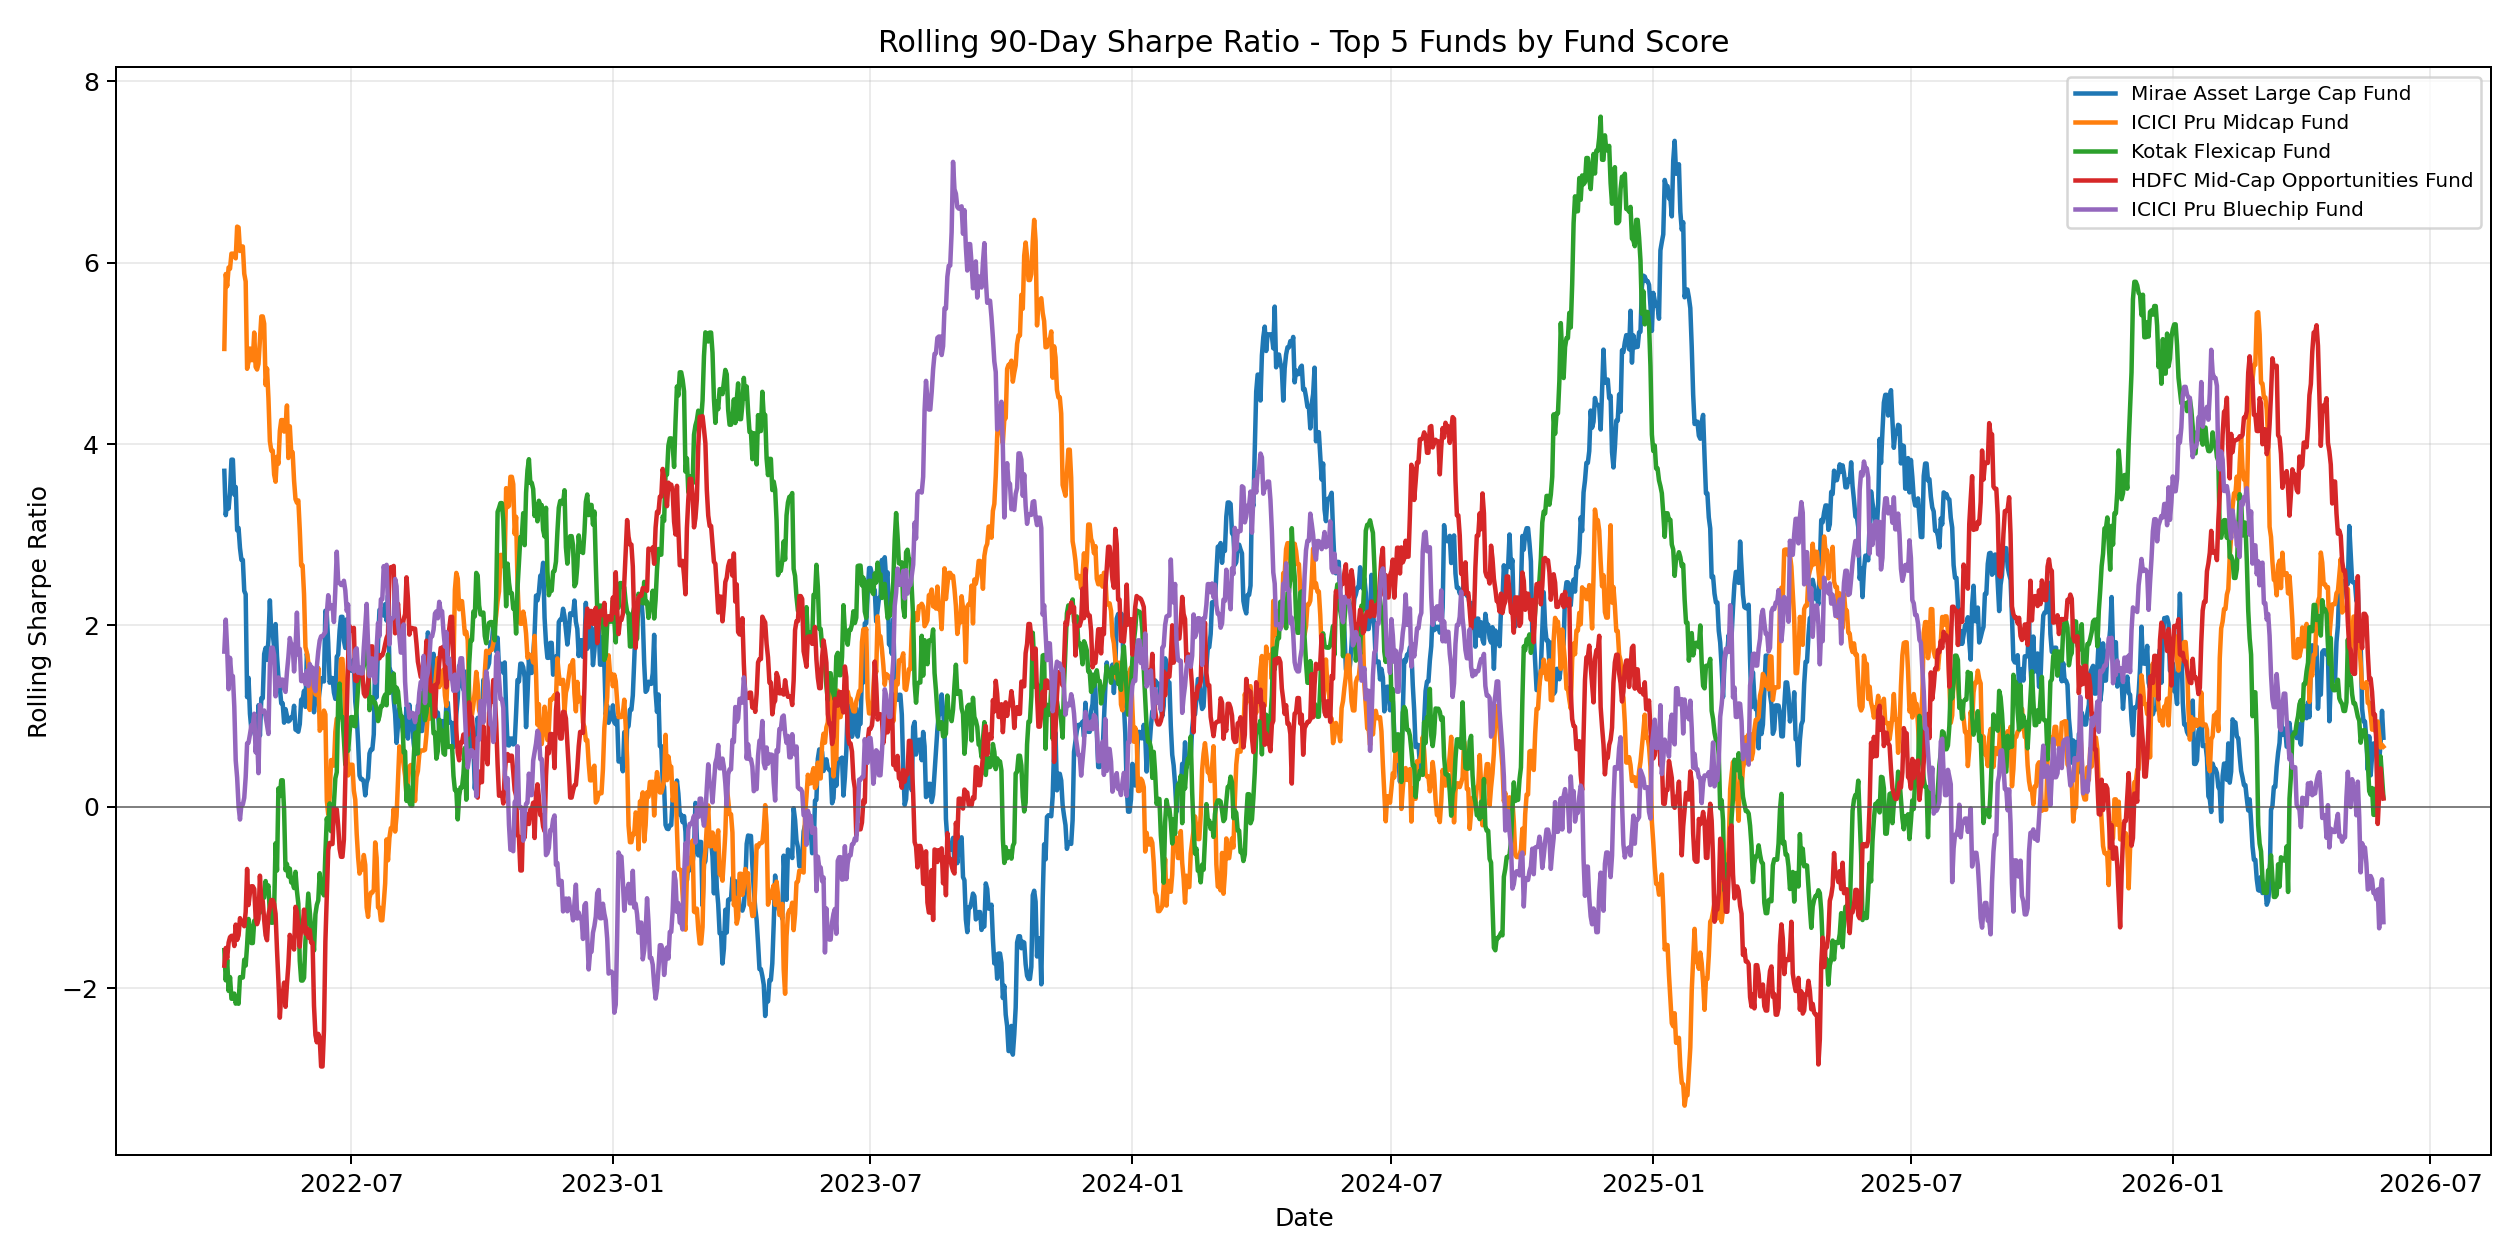

In [3]:
from IPython.display import Image
top_5_rolling_sharpe_amfi_codes = [148567, 120505, 120843, 100033, 120504]
Image(filename="rolling_sharpe_chart.png")

## Investor Cohort Analysis

In [4]:
display(pd.DataFrame([{'first_transaction_year': 2024, 'investors': 4624, 'sip_transactions': 19549, 'avg_sip_amount': 10996.885825361911, 'total_invested': 214978121, 'top_fund_preference': 'HDFC Mid-Cap Opportunities Fund - Direct - Growth', 'top_fund_sip_amount': 6268480}, {'first_transaction_year': 2025, 'investors': 138, 'sip_transactions': 167, 'avg_sip_amount': 13505.209580838324, 'total_invested': 2255370, 'top_fund_preference': 'SBI Small Cap Fund - Direct Plan - Growth', 'top_fund_sip_amount': 174133}]))

,first_transaction_year,investors,sip_transactions,avg_sip_amount,total_invested,top_fund_preference,top_fund_sip_amount
0,2024,4624,19549,10996.885825,214978121,HDFC Mid-Cap Opportunities Fund - Direct - Growth,6268480
1,2025,138,167,13505.209581,2255370,SBI Small Cap Fund - Direct Plan - Growth,174133


## SIP Continuity Analysis

In [5]:
sip_continuity_summary = {'eligible_investors': 1362.0, 'at_risk_investors': 1332.0, 'continuity_rate_pct': 2.2026431718061676, 'avg_gap_days': 64.88913209078407}
display(pd.DataFrame([sip_continuity_summary]))
display(pd.DataFrame([{'investor_id': 'INV000566', 'sip_transactions': 7, 'avg_gap_days': 35.0, 'max_gap_days': 119.0, 'total_sip_amount': 117813, 'status': 'continuous'}, {'investor_id': 'INV003772', 'sip_transactions': 9, 'avg_gap_days': 34.5, 'max_gap_days': 72.0, 'total_sip_amount': 26850, 'status': 'continuous'}, {'investor_id': 'INV000707', 'sip_transactions': 9, 'avg_gap_days': 34.375, 'max_gap_days': 106.0, 'total_sip_amount': 48062, 'status': 'continuous'}, {'investor_id': 'INV003382', 'sip_transactions': 6, 'avg_gap_days': 34.2, 'max_gap_days': 85.0, 'total_sip_amount': 67494, 'status': 'continuous'}, {'investor_id': 'INV004246', 'sip_transactions': 7, 'avg_gap_days': 34.166666666666664, 'max_gap_days': 64.0, 'total_sip_amount': 96467, 'status': 'continuous'}, {'investor_id': 'INV004927', 'sip_transactions': 7, 'avg_gap_days': 34.166666666666664, 'max_gap_days': 63.0, 'total_sip_amount': 93464, 'status': 'continuous'}, {'investor_id': 'INV001672', 'sip_transactions': 9, 'avg_gap_days': 34.0, 'max_gap_days': 130.0, 'total_sip_amount': 85714, 'status': 'continuous'}, {'investor_id': 'INV004542', 'sip_transactions': 7, 'avg_gap_days': 34.0, 'max_gap_days': 59.0, 'total_sip_amount': 57880, 'status': 'continuous'}, {'investor_id': 'INV003650', 'sip_transactions': 11, 'avg_gap_days': 33.9, 'max_gap_days': 86.0, 'total_sip_amount': 40805, 'status': 'continuous'}, {'investor_id': 'INV002509', 'sip_transactions': 10, 'avg_gap_days': 33.666666666666664, 'max_gap_days': 74.0, 'total_sip_amount': 116029, 'status': 'continuous'}]))

,eligible_investors,at_risk_investors,continuity_rate_pct,avg_gap_days
0,1362.0,1332.0,2.202643,64.889132


,investor_id,sip_transactions,avg_gap_days,max_gap_days,total_sip_amount,status
0,INV000566,7,35.000000,119.0,117813,continuous
1,INV003772,9,34.500000,72.0,26850,continuous
2,INV000707,9,34.375000,106.0,48062,continuous
3,INV003382,6,34.200000,85.0,67494,continuous
4,INV004246,7,34.166667,64.0,96467,continuous
5,INV004927,7,34.166667,63.0,93464,continuous
6,INV001672,9,34.000000,130.0,85714,continuous
7,INV004542,7,34.000000,59.0,57880,continuous
8,INV003650,11,33.900000,86.0,40805,continuous
9,INV002509,10,33.666667,74.0,116029,continuous


## Simple Fund Recommender

In [6]:
display(pd.DataFrame([{'amfi_code': 148567, 'scheme_name': 'Mirae Asset Large Cap Fund - Regular - Growth', 'fund_house': 'Mirae Asset MF', 'category': 'Equity', 'sub_category': 'Large Cap', 'risk_category': 'Moderate', 'sharpe_ratio': 1.0682238272314732, 'annualized_return': 0.1934539923571092, 'annualized_volatility': 0.1202500722063322, 'fund_score': 85.89743589743588}, {'amfi_code': 119551, 'scheme_name': 'SBI Bluechip Fund - Regular Plan - Growth', 'fund_house': 'SBI Mutual Fund', 'category': 'Equity', 'sub_category': 'Large Cap', 'risk_category': 'Moderate', 'sharpe_ratio': 0.8609773262277756, 'annualized_return': 0.1651879867152076, 'annualized_volatility': 0.1163654183022032, 'fund_score': 73.71794871794872}, {'amfi_code': 118632, 'scheme_name': 'Nippon India Large Cap Fund - Regular - Growth', 'fund_house': 'Nippon India MF', 'category': 'Equity', 'sub_category': 'Large Cap', 'risk_category': 'Moderate', 'sharpe_ratio': 0.7588510310771438, 'annualized_return': 0.155895741799891, 'annualized_volatility': 0.1197807449386607, 'fund_score': 65.8974358974359}]))

,amfi_code,scheme_name,fund_house,category,sub_category,risk_category,sharpe_ratio,annualized_return,annualized_volatility,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Large Cap,Moderate,1.068224,0.193454,0.120250,85.897436
1,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,Moderate,0.860977,0.165188,0.116365,73.717949
2,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Large Cap,Moderate,0.758851,0.155896,0.119781,65.897436


## Sector HHI Concentration

In [7]:
display(pd.DataFrame([{'amfi_code': 119092, 'sector_hhi': 0.29676908999999996, 'scheme_name': 'Axis Bluechip Fund - Regular - Growth', 'fund_house': 'Axis Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 148569, 'sector_hhi': 0.25499194, 'scheme_name': 'Mirae Asset Tax Saver Fund - Regular - Growth', 'fund_house': 'Mirae Asset MF', 'sub_category': 'ELSS', 'risk_category': 'High'}, {'amfi_code': 125498, 'sector_hhi': 0.253155, 'scheme_name': 'HDFC Mid-Cap Opportunities Fund - Direct - Growth', 'fund_house': 'HDFC Mutual Fund', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 102887, 'sector_hhi': 0.25138255, 'scheme_name': 'UTI Flexi Cap Fund - Regular - Growth', 'fund_house': 'UTI Mutual Fund', 'sub_category': 'Flexi Cap', 'risk_category': 'Moderately High'}, {'amfi_code': 149323, 'sector_hhi': 0.24107663999999998, 'scheme_name': 'DSP Midcap Fund - Regular - Growth', 'fund_house': 'DSP Mutual Fund', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 120505, 'sector_hhi': 0.23869504, 'scheme_name': 'ICICI Pru Midcap Fund - Regular - Growth', 'fund_house': 'ICICI Prudential MF', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 118635, 'sector_hhi': 0.23749677, 'scheme_name': 'Nippon India ETF Nifty 50 BeES', 'fund_house': 'Nippon India MF', 'sub_category': 'Index/ETF', 'risk_category': 'Moderate'}, {'amfi_code': 119599, 'sector_hhi': 0.2323612, 'scheme_name': 'SBI Small Cap Fund - Direct Plan - Growth', 'fund_house': 'SBI Mutual Fund', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 120506, 'sector_hhi': 0.23146434, 'scheme_name': 'ICICI Pru Value Discovery Fund - Regular - Growth', 'fund_house': 'ICICI Prudential MF', 'sub_category': 'Value', 'risk_category': 'Moderately High'}, {'amfi_code': 100033, 'sector_hhi': 0.22764743999999998, 'scheme_name': 'HDFC Mid-Cap Opportunities Fund - Regular - Growth', 'fund_house': 'HDFC Mutual Fund', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 119552, 'sector_hhi': 0.22750834999999997, 'scheme_name': 'SBI Bluechip Fund - Direct Plan - Growth', 'fund_house': 'SBI Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 101207, 'sector_hhi': 0.22272651000000002, 'scheme_name': 'ABSL Small Cap Fund - Regular - Growth', 'fund_house': 'Aditya Birla Sun Life MF', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 120504, 'sector_hhi': 0.22121302999999998, 'scheme_name': 'ICICI Pru Bluechip Fund - Direct - Growth', 'fund_house': 'ICICI Prudential MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 118633, 'sector_hhi': 0.22120031999999998, 'scheme_name': 'Nippon India Large Cap Fund - Direct - Growth', 'fund_house': 'Nippon India MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 148568, 'sector_hhi': 0.21808584999999997, 'scheme_name': 'Mirae Asset Emerging Bluechip Fund - Regular - Growth', 'fund_house': 'Mirae Asset MF', 'sub_category': 'Large & Mid Cap', 'risk_category': 'Moderately High'}, {'amfi_code': 120841, 'sector_hhi': 0.21589315000000003, 'scheme_name': 'Kotak Bluechip Fund - Regular - Growth', 'fund_house': 'Kotak Mahindra MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 118632, 'sector_hhi': 0.20725894, 'scheme_name': 'Nippon India Large Cap Fund - Regular - Growth', 'fund_house': 'Nippon India MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 148567, 'sector_hhi': 0.20124815000000001, 'scheme_name': 'Mirae Asset Large Cap Fund - Regular - Growth', 'fund_house': 'Mirae Asset MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 149324, 'sector_hhi': 0.18870082000000002, 'scheme_name': 'DSP Small Cap Fund - Regular - Growth', 'fund_house': 'DSP Mutual Fund', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 119598, 'sector_hhi': 0.18808485000000003, 'scheme_name': 'SBI Small Cap Fund - Regular Plan - Growth', 'fund_house': 'SBI Mutual Fund', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 119093, 'sector_hhi': 0.18423319999999999, 'scheme_name': 'Axis Bluechip Fund - Direct - Growth', 'fund_house': 'Axis Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 149322, 'sector_hhi': 0.18269533, 'scheme_name': 'DSP Top 100 Equity Fund - Regular - Growth', 'fund_house': 'DSP Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 120503, 'sector_hhi': 0.1821675, 'scheme_name': 'ICICI Pru Bluechip Fund - Regular - Growth', 'fund_house': 'ICICI Prudential MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 102885, 'sector_hhi': 0.18071201999999997, 'scheme_name': 'UTI Nifty 50 Index Fund - Regular - Growth', 'fund_house': 'UTI Mutual Fund', 'sub_category': 'Index', 'risk_category': 'Moderate'}, {'amfi_code': 100016, 'sector_hhi': 0.18058807999999998, 'scheme_name': 'HDFC Top 100 Fund - Regular Plan - Growth', 'fund_house': 'HDFC Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 101206, 'sector_hhi': 0.18004225000000001, 'scheme_name': 'ABSL Frontline Equity Fund - Regular - Growth', 'fund_house': 'Aditya Birla Sun Life MF', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 119094, 'sector_hhi': 0.17510024999999999, 'scheme_name': 'Axis Midcap Fund - Regular - Growth', 'fund_house': 'Axis Mutual Fund', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 125497, 'sector_hhi': 0.17241088, 'scheme_name': 'HDFC Top 100 Fund - Direct Plan - Growth', 'fund_house': 'HDFC Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 120842, 'sector_hhi': 0.16206189, 'scheme_name': 'Kotak Emerging Equity Fund - Regular - Growth', 'fund_house': 'Kotak Mahindra MF', 'sub_category': 'Mid Cap', 'risk_category': 'High'}, {'amfi_code': 118634, 'sector_hhi': 0.16029924, 'scheme_name': 'Nippon India Small Cap Fund - Regular - Growth', 'fund_house': 'Nippon India MF', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 119095, 'sector_hhi': 0.15958229000000002, 'scheme_name': 'Axis Small Cap Fund - Regular - Growth', 'fund_house': 'Axis Mutual Fund', 'sub_category': 'Small Cap', 'risk_category': 'Very High'}, {'amfi_code': 119551, 'sector_hhi': 0.14249103999999999, 'scheme_name': 'SBI Bluechip Fund - Regular Plan - Growth', 'fund_house': 'SBI Mutual Fund', 'sub_category': 'Large Cap', 'risk_category': 'Moderate'}, {'amfi_code': 120843, 'sector_hhi': 0.13620616000000002, 'scheme_name': 'Kotak Flexicap Fund - Regular - Growth', 'fund_house': 'Kotak Mahindra MF', 'sub_category': 'Flexi Cap', 'risk_category': 'Moderately High'}, {'amfi_code': 102886, 'sector_hhi': 0.12402024, 'scheme_name': 'UTI Mid Cap Fund - Regular - Growth', 'fund_house': 'UTI Mutual Fund', 'sub_category': 'Mid Cap', 'risk_category': 'High'}]))

,amfi_code,sector_hhi,scheme_name,fund_house,sub_category,risk_category
0,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Moderate
1,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,High
2,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,High
3,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Moderately High
4,149323,0.241077,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,High
5,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High
6,118635,0.237497,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Moderate
7,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Very High
8,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,Moderately High
9,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,High



## Advanced Insights

1. **Highest daily VaR risk:** ABSL Small Cap Fund - Regular - Growth has the deepest 95% historical VaR at -2.3915%, implying a one-day tail loss of about 2.39% at the 5th percentile.
2. **Worst expected tail loss:** ABSL Small Cap Fund - Regular - Growth has the weakest CVaR at -3.0289%, meaning days beyond its VaR threshold averaged a 3.03% loss.
3. **Largest investor cohort:** Investors whose first transaction year was 2024 invested the most via SIPs, with Rs 214,978,121 total SIP investment and average SIP size of Rs 10,997.
4. **SIP continuity:** Among investors with at least 6 SIP transactions, the continuity rate is 2.20%; 97.80% are flagged as at-risk because their average SIP gap is above 35 days.
5. **Sector concentration:** Axis Bluechip Fund - Regular - Growth is the most concentrated equity portfolio with HHI 0.2968, while UTI Mid Cap Fund - Regular - Growth is the most diversified among equity funds with HHI 0.1240.
